# Issue #44 — levels_reversal vs ATR reversal
Сравнение двух стратегий на общем портфеле 50,000 RUB. Ноутбук загружает зафиксированные JSON-прогоны, проверяет их контракт, строит метрики и воспроизводит все артефакты отчёта.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Markdown, Image

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'analysis.py').exists():
    ANALYSIS_DIR = Path('analytics/issue-44-strategy-comparison').resolve()
sys.path.insert(0, str(ANALYSIS_DIR))
from analysis import run_analysis, DISPLAY_NAMES

## Расчёт
`run_analysis()` валидирует стратегию, стартовый капитал и структуру обоих входов. Daily equity строится по моментам закрытия сделок, поэтому это realized equity без mark-to-market.

In [2]:
analysis = run_analysis()
analysis['metrics']

,final_equity_rub,pnl_rub,pnl_pct,n_trades,win_rate_pct,profit_factor,event_max_drawdown_pct,game_over,skipped_entries,max_drawdown_pct,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_peak_equity_rub,max_drawdown_trough_equity_rub,max_drawdown_rub
strategy,,,,,,,,,,,,,,,
levels_reversal,96343.49,46343.49,92.69,3500,28.3,1.31,5.93,False,1452,5.47,2025-02-17,2025-03-13,69462.03,65663.24,3798.79
atr_reversal,45587.14,-4412.86,-8.83,912,38.8,0.36,8.95,False,0,8.93,2024-09-27,2026-08-14,50058.00,45587.00,4471.00


## Equity-кривые

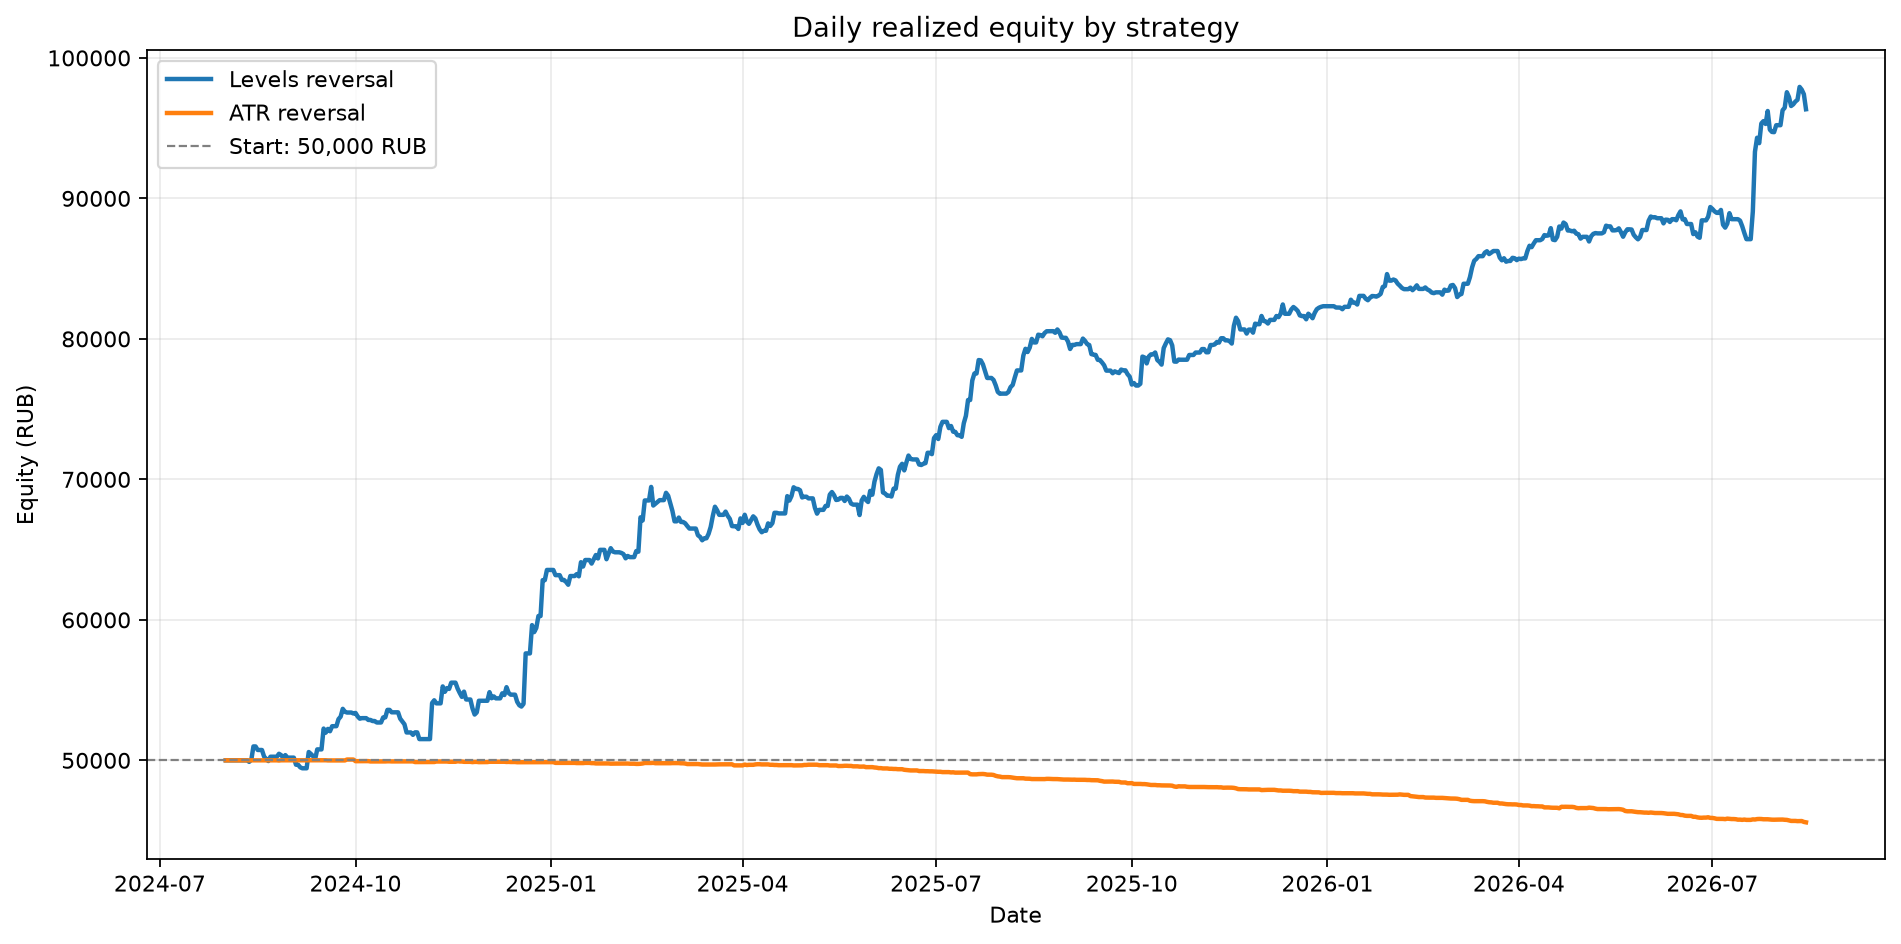

In [3]:
display(Image(filename=str(ANALYSIS_DIR / 'plots/equity_curves.png')))

## Распределение PnL сделок

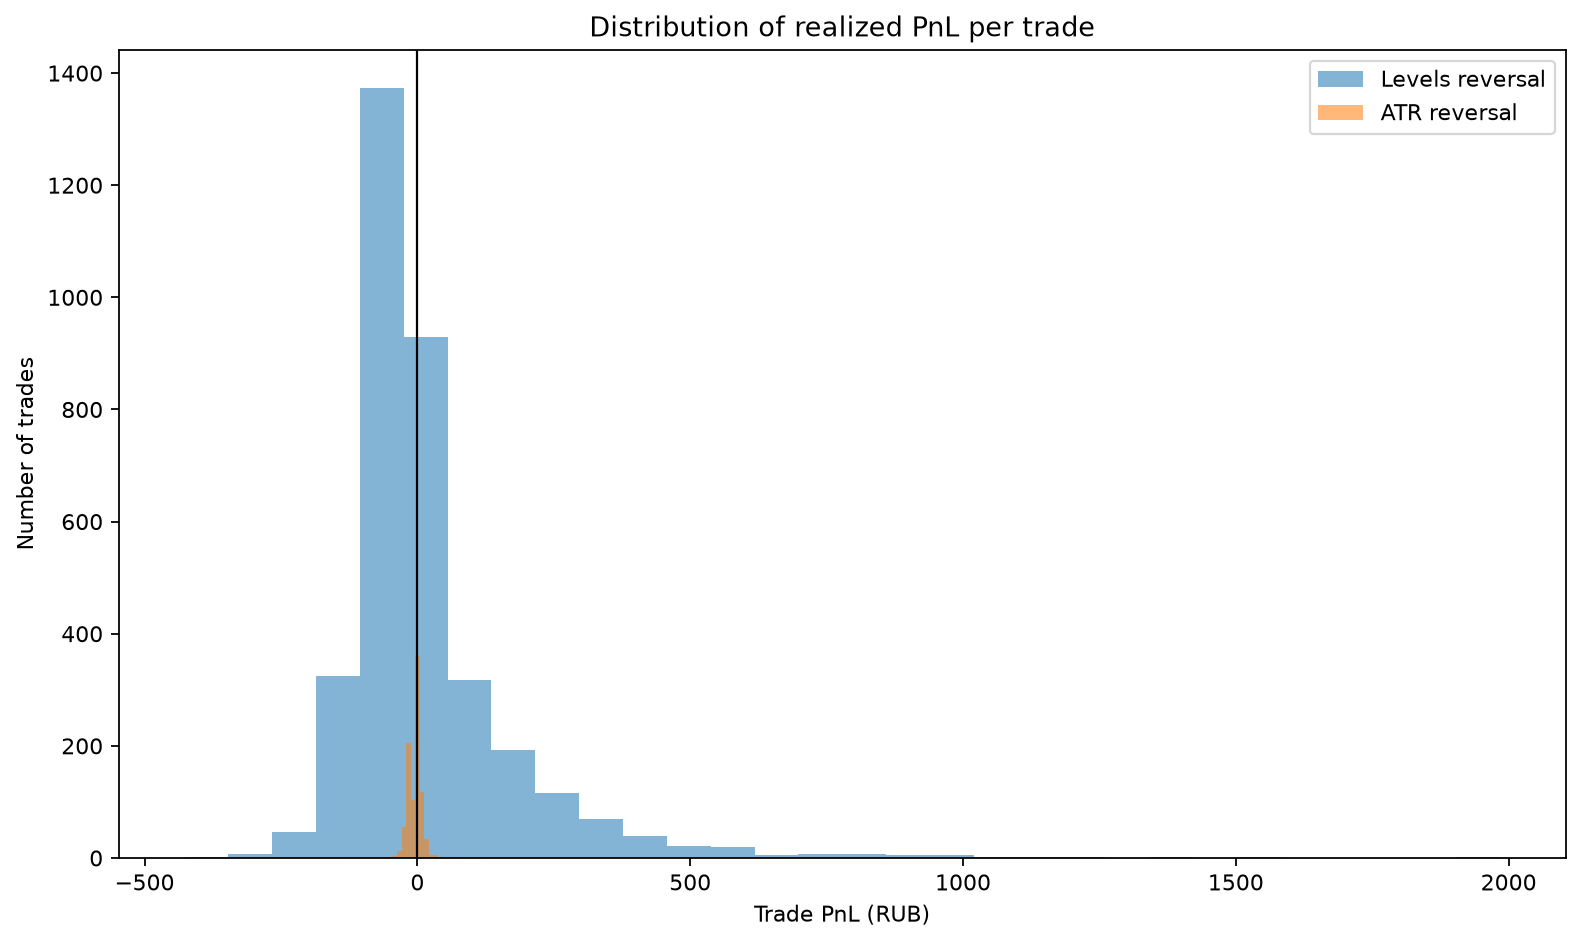

In [4]:
display(Image(filename=str(ANALYSIS_DIR / 'plots/trade_pnl_distribution.png')))

## Результаты по тикерам

n_trades                      pnl_rub                
strategy atr_reversal levels_reversal atr_reversal levels_reversal
ticker                                                            
AFKS             34.0            95.0      -136.98         2002.06
ALRS             20.0           115.0       -53.80          879.58
CBOM             31.0           242.0       -22.34         2646.33
CHMF             30.0            89.0      -247.01         -495.27
FEES             40.0           140.0      -284.33         2412.81
FLOT             55.0           223.0      -147.96         2316.96
GAZP             39.0            75.0      -198.39         1896.20
GMKN             41.0            89.0      -300.64         3159.78
IRAO             37.0           153.0      -144.75         2179.93
LKOH             23.0            94.0       -84.99         1643.33
MGNT             22.0           100.0      -144.74         -481.06
MOEX             42.0           148.0      -161.11         -713.84
MTLR              9.0            86.0       -87.72         3079.09
MTSS             32.0            86.0      -160.13          409.37
NLMK             26.0            99.0      -148.15         -225.17
NVTK             33.0           126.0      -180.88         2478.81
PHOR             33.0           199.0      -121.83         1782.94
PIKK             35.0           114.0      -139.92         5085.23
PLZL             21.0           137.0       -45.30         2109.99
ROSN             31.0           139.0      -159.91         3096.97
RTKM             26.0            88.0       -95.35          708.55
RUAL             42.0            99.0      -217.92         2883.19
SBER             33.0           135.0       -50.84         -257.03
SIBN             29.0           119.0      -204.34         1586.52
SNGS             33.0           131.0      -139.50         1424.43
TATN             32.0           135.0      -230.99         2491.10
TRNFP            44.0           124.0      -343.48         1450.44
VTBR             39.0           120.0      -159.70          792.34

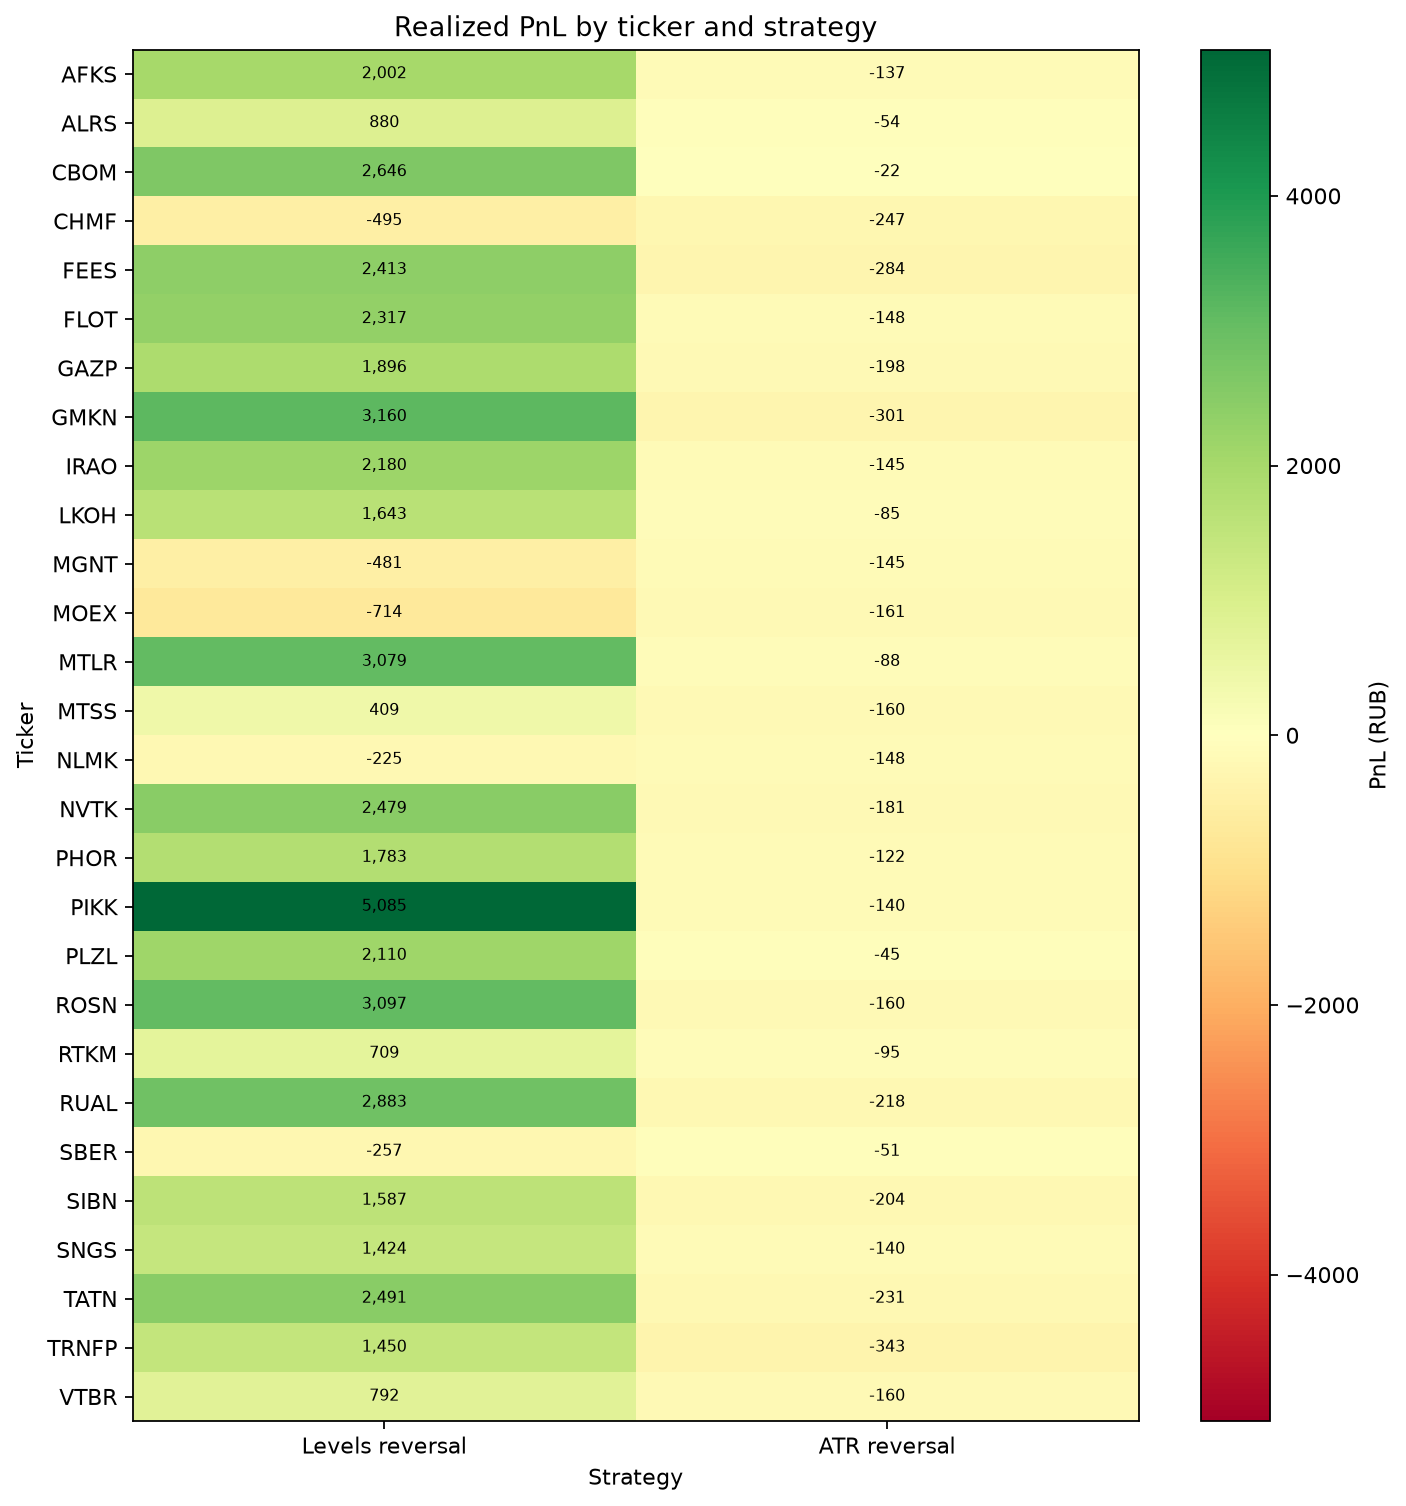

In [5]:
ticker_pivot = analysis['tickers'].pivot(
    index='ticker', columns='strategy', values=['n_trades', 'pnl_rub']
)
display(ticker_pivot)
display(Image(filename=str(ANALYSIS_DIR / 'plots/ticker_pnl_heatmap.png')))

## Результаты по месяцам

In [6]:
monthly_pnl = analysis['monthly'].pivot(
    index='month', columns='strategy', values='pnl_rub'
).fillna(0)
monthly_pnl

strategy,atr_reversal,levels_reversal
month,,
2024-08,2.40,192.88
2024-09,54.77,3143.07
2024-10,-179.51,-1824.27
2024-11,-5.14,2729.06
2024-12,0.01,9311.10
2025-01,-104.24,1257.20
2025-02,36.75,2205.25
2025-03,-164.10,208.61
2025-04,31.71,1542.27


## GAME OVER

In [7]:
{strategy: {
    'game_over': result.get('game_over'),
    'game_over_ts': result.get('game_over_ts'),
} for strategy, result in analysis['results'].items()}

{'levels_reversal': {'game_over': False, 'game_over_ts': None},
 'atr_reversal': {'game_over': False, 'game_over_ts': None}}

## Итоговый отчёт

In [8]:
display(Markdown((ANALYSIS_DIR / 'report.md').read_text(encoding='utf-8')))

# Issue #44: levels_reversal vs ATR reversal

## Резюме

На фиксированном портфеле 50,000 RUB лучший итог показала **Levels reversal**:
её PnL выше на 50,756.35 RUB.
Это сравнение является историческим бэктестом и не доказывает будущую доходность.

## Методика

- Период: `2024-08-01` — `2026-08-15`.
- Общий капитал: 50,000 RUB; слот: 10,000 RUB; максимум 5 позиций.
- Комиссия включена в `net_return_pct` симулятора.
- Equity по дням реконструирована по закрытым сделкам (realized PnL), без mark-to-market
  открытых позиций.
- Max DD в сравнительной таблице рассчитан по equity на конец дня. Event-based
  просадка симулятора приведена отдельно.
- Одинаковый порядок тикеров и правила конкуренции за слот применены к обеим стратегиям.

## Сравнительные метрики

| Стратегия | Итоговый equity, RUB | PnL, RUB | PnL, % | Сделки | Win rate | Profit factor | Max DD | GAME OVER |
|---|---:|---:|---:|---:|---:|---:|---:|:---:|
| Levels reversal | 96,343.49 | +46,343.49 | +92.69% | 3500 | 28.3% | 1.31 | 5.47% | нет |
| ATR reversal | 45,587.14 | -4,412.86 | -8.83% | 912 | 38.8% | 0.36 | 8.93% | нет |

![Equity curves](plots/equity_curves.png)

### Максимальная просадка

- **Levels reversal:** 5.47% с 2025-02-17 по 2025-03-13; equity снизилась с 69,462.03 до 65,663.24 RUB (−3,798.79 RUB). Event-based Max DD симулятора: 5.93%.
- **ATR reversal:** 8.93% с 2024-09-27 по 2026-08-14; equity снизилась с 50,058.00 до 45,587.00 RUB (−4,471.00 RUB). Event-based Max DD симулятора: 8.95%.

## Анализ сделок и тикеров

![Trade PnL distribution](plots/trade_pnl_distribution.png)

![Ticker PnL heatmap](plots/ticker_pnl_heatmap.png)

### Лучшие и худшие тикеры

- **Levels reversal, больше всего сделок:** CBOM (242 сделок), FLOT (223 сделок), PHOR (199 сделок), IRAO (153 сделок), MOEX (148 сделок).
- **ATR reversal, больше всего сделок:** FLOT (55 сделок), TRNFP (44 сделок), MOEX (42 сделок), RUAL (42 сделок), GMKN (41 сделок).
- **Levels reversal, прибыльные:** PIKK (+5,085 RUB, 114 сделок), GMKN (+3,160 RUB, 89 сделок), ROSN (+3,097 RUB, 139 сделок), MTLR (+3,079 RUB, 86 сделок), RUAL (+2,883 RUB, 99 сделок).
- **Levels reversal, убыточные:** MOEX (-714 RUB, 148 сделок), CHMF (-495 RUB, 89 сделок), MGNT (-481 RUB, 100 сделок), SBER (-257 RUB, 135 сделок), NLMK (-225 RUB, 99 сделок).
- **ATR reversal, прибыльные:** нет тикеров минимум с 3 сделками.
- **ATR reversal, убыточные:** TRNFP (-343 RUB, 44 сделок), GMKN (-301 RUB, 41 сделок), FEES (-284 RUB, 40 сделок), CHMF (-247 RUB, 30 сделок), TATN (-231 RUB, 32 сделок).

## Анализ по месяцам

- **Levels reversal:** прибыльные месяцы — 2024-08, 2024-09, 2024-11, 2024-12, 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2025-10, 2025-11, 2025-12, 2026-01, 2026-03, 2026-04, 2026-05, 2026-06, 2026-07, 2026-08; убыточные — 2024-10, 2025-09, 2026-02.
- **ATR reversal:** прибыльные месяцы — 2024-08, 2024-09, 2024-12, 2025-02, 2025-04; убыточные — 2024-10, 2024-11, 2025-01, 2025-03, 2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2026-04, 2026-05, 2026-06, 2026-07, 2026-08.

## GAME OVER

- **Levels reversal:** GAME OVER не наступил.
- **ATR reversal:** GAME OVER не наступил.

## Рекомендации

- **Levels reversal:** допустим только ограниченный forward paper trading; переход к реальному капиталу возможен лишь после положительных walk-forward и forward-результатов (daily Max DD 5.47%).
- **ATR reversal:** запуск не рекомендован до положительного walk-forward результата.

1. Для paper trading использовать только стратегию с положительным PnL, PF > 1,
   минимум 30 сделками и без GAME OVER; ограничить размер позиции и задать stop-критерий
   по drawdown.
2. Для ATR reversal прогнать walk-forward сетку:
   `atr_completion=0.75..0.95`, `volume_spike_mult=1.5..2.5`,
   `stop_atr_mult=0.75..1.25`, `take_atr_mult=0.85..1.50`.
3. Тикерные фильтры строить только на in-sample части и подтверждать на следующем
   временном окне; не исключать тикеры по этому full-sample результату напрямую.
4. Следующая итерация должна добавить mark-to-market equity и сравнение с buy-and-hold,
   чтобы drawdown учитывал открытые позиции.

## Воспроизводимость

- `levels_reversal` SHA-256: `c1c0a576eefdfcb3b90e53b397f652d2d0f4a3375bfc2ee0834fcb23800723c3`
- `atr_reversal` SHA-256: `ac7905c6a2636d71b1156f4a1eb5e8b856f791d2982bbc8df98818a020269aa5`
- Код расчётов: `analysis.py`; интерактивный walkthrough: `analysis.ipynb`.

![Metrics comparison](plots/metrics_comparison.png)
